In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt
from astropy.io import fits
from lmfit.model import load_modelresult


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()  # asumiendo que abres Jupyter en la raíz del repo

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR
import results_comp
import plot_fit_params
import ci_results_compiler
import bfunc

In [3]:
H_file_name  = "MUSE-M42-Ar-bin0"
#Hsbm_file_name  = "MUSE-M42-H-sbmask"
H1_file_name = "MUSE-M42-Ar-bin1"
H2_file_name = "MUSE-M42-Ar-bin2"
H3_file_name = "MUSE-M42-Ar-bin3"
H4_file_name = "MUSE-M42-Ar-bin4"

labels = [
         'Ar0',
      #    'Hsbm',
          'Ar1',
          'Ar2',
          'Ar3',
    'Ar4'
         ]

In [4]:
H_ = results_comp.load_line_bundle_mat(H_file_name, "H_line", MAPS_DIR, read_header=True)
#Hsbm_ = results_comp.load_line_bundle_mat(Hsbm_file_name, "Hsbm_line", MAPS_DIR, read_header=True)
H1_ = results_comp.load_line_bundle_mat(H1_file_name, "H1_line", MAPS_DIR, read_header=True)
H2_ = results_comp.load_line_bundle_mat(H2_file_name, "H2_line", MAPS_DIR, read_header=True)
H3_ = results_comp.load_line_bundle_mat(H3_file_name, "H3_line", MAPS_DIR, read_header=True)
H4_ = results_comp.load_line_bundle_mat(H4_file_name, "H4_line", MAPS_DIR, read_header=True)


obs = [
    H_['meta']['SIG2'], 
 #   Hsbm_['meta']['SIG2'], 
    H1_['meta']['SIG2'], 
    H2_['meta']['SIG2'],
    H3_['meta']['SIG2'],
    H4_['meta']['SIG2']
]


In [5]:
H_line = H_['fit'].to_dict(orient='list')
#Hsbm_line = Hsbm_['fit'].to_dict(orient='list')
H1_line = H1_['fit'].to_dict(orient='list')
H2_line = H2_['fit'].to_dict(orient='list')
H3_line = H3_['fit'].to_dict(orient='list')
H4_line = H4_['fit'].to_dict(orient='list')


# Pdfs


In [6]:
H_mask = (H_['mask'] !=0)
#Hsbm_mask = (Hsbm_['mask'] !=0)
H1_mask = (H1_['mask'] !=0)
H2_mask = (H2_['mask'] !=0)
H3_mask = (H3_['mask'] !=0)
H4_mask = (H4_['mask'] !=0)


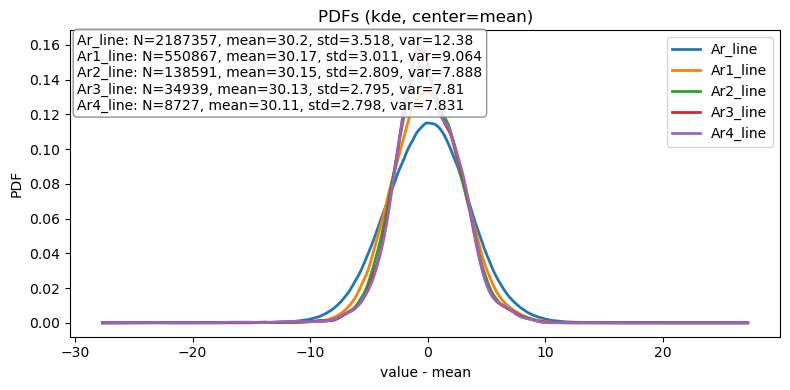

In [7]:
import matrix_plots 

arrays = {"Ar_line": H_["vv"][H_mask],
         # "Hsbm_line": Hsbm_["vv"][Hsbm_mask],
          "Ar1_line": H1_["vv"][H1_mask], 
          "Ar2_line": H2_["vv"][H2_mask], 
          "Ar3_line": H3_["vv"][H3_mask],
         "Ar4_line": H4_["vv"][H4_mask],
         }
fig, ax = matrix_plots.plot_pdfs(arrays, center="mean", method="kde", bw_scale=1.0)
plt.savefig('Imgs/pdfs Ar.jpg', bbox_inches='tight')

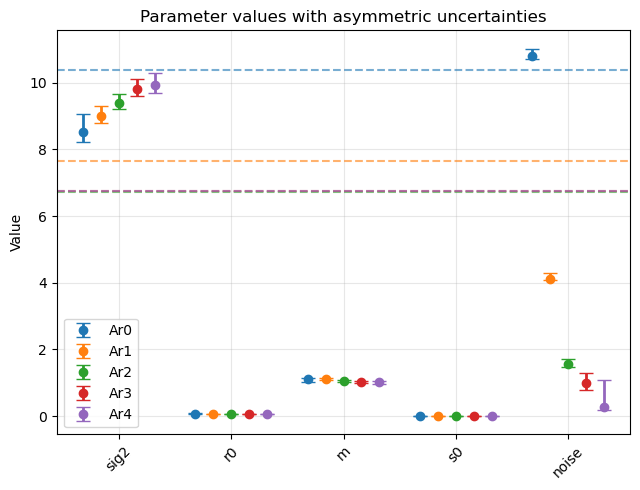

In [8]:

plot_fit_params.plot_param_comp_obs(H_line,
                                  #  Hsbm_line,
                                    H1_line, 
                                    H2_line, 
                                    H3_line, 
                                    H4_line,
                                    labels=labels, obs=obs)

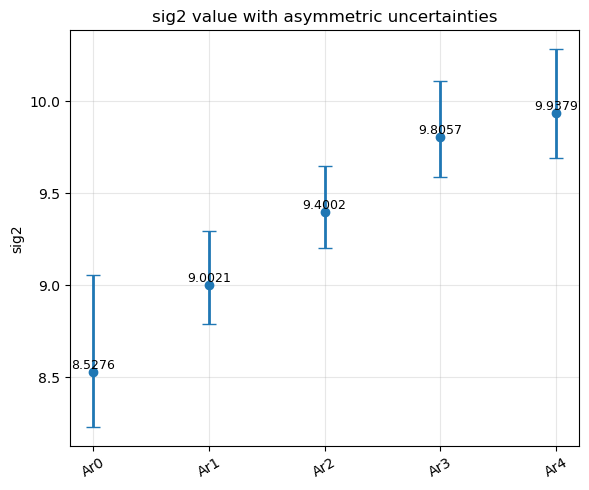

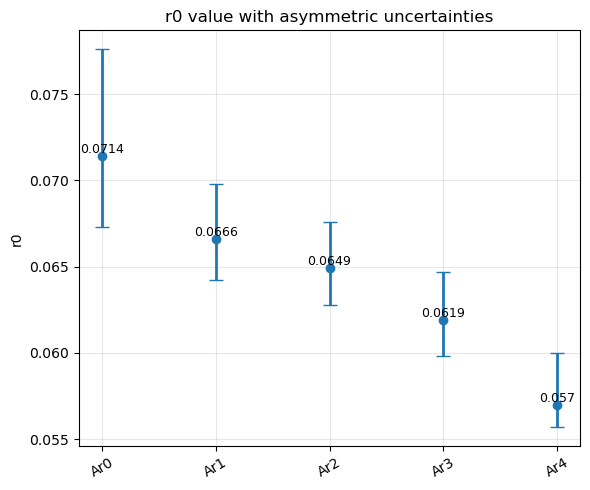

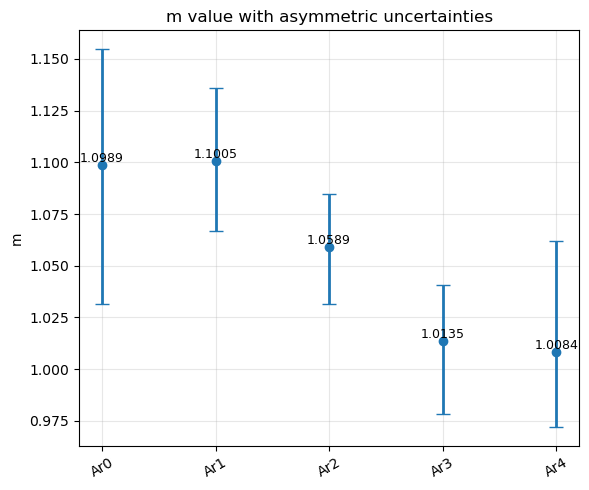

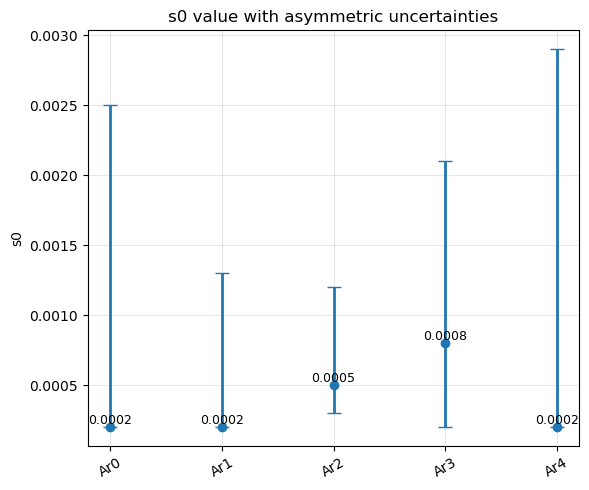

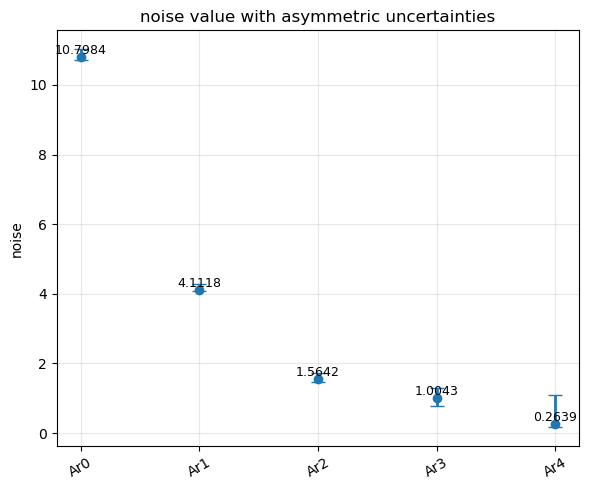

In [9]:
plot_fit_params.plot_param(H_line, 
                      #     Hsbm_line,
                           H1_line, 
                           H2_line, 
                           H3_line, 
                           H4_line, 
                           labels=labels,  decimals=4)


# Br plots comparison

In [10]:
raw_bundles = {
    r'1$\times$1': H_,
   # 'Bin 0 sbm': Hsbm_,
    r'2$\times$2': H1_,
    r'4$\times$4': H2_,    
    r'8$\times$8': H3_, 
    r'16$\times$16': H4_,
}

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def bundle_to_plot_data(bundle, fit_row=0, use_weighted=False):
    """
    Convierte un bundle tipo H_ a un diccionario estándar para plotting.

    Parámetros
    ----------
    bundle : dict
        Diccionario con llaves como 'Br', 'fit', 'meta'
    fit_row : int
        Qué fila de bundle['fit'] usar
    use_weighted : bool
        Si True usa 'Weighted B(r)', si False usa 'Unweighted B(r)'
    """
    Br = bundle['Br']
    fit = bundle['fit']
    meta = bundle['meta']

    bcol = 'Weighted B(r)' if use_weighted else 'Unweighted B(r)'

    mask = np.array(Br['N pairs']) > 0

    r = (10 ** np.array(Br['log10 r'])[mask]) * meta['PIX'] * meta['PC']
    B = np.array(Br[bcol])[mask]

    d = {
        'r': r,
        'B': B,
        'sig': meta.get('SIG', None),
        'sig2_meta': meta.get('SIG2', None),   # valor proveniente de meta
        's0_meta': meta.get('S0', None),       # valor proveniente de meta
        'pc': meta.get('PC', None),
        'pix': meta.get('PIX', None),
        'line': meta.get('LINE', None),
        'binsize': meta.get('BINSIZE', None),

        # parámetros del ajuste
        'sig2': fit.iloc[fit_row]['sig2'] if 'sig2' in fit.columns else None,
        'r0':   fit.iloc[fit_row]['r0']   if 'r0'   in fit.columns else None,
        'm':    fit.iloc[fit_row]['m']    if 'm'    in fit.columns else None,
        's0':   fit.iloc[fit_row]['s0']   if 's0'   in fit.columns else None,
        'noise':fit.iloc[fit_row]['noise']if 'noise'in fit.columns else None,
    }

    return d

In [12]:
data = {
    name: bundle_to_plot_data(bundle, fit_row=0, use_weighted=False)
    for name, bundle in raw_bundles.items()
}

data_in = list(data.keys())

In [13]:
colors = sns.color_palette("Greys_d", n_colors=len(data_in))[::-1]
#colors = sns.color_palette("Grays_d", n_colors=len(data_in))
#colors = plt.cm.viridis(np.linspace(0, 1, len(data_in)))

markers = ['o', 'o', 'o', 'o', 'o', 'o', '+', '+', 's', 's', 's', 's', '.', '.', '.', '.']

annot_x = 0.0001
log_y_positions = np.logspace(1.5, 1.0, len(data_in))
annotation_coords = {
    name: (annot_x, y)
    for name, y in zip(data_in, log_y_positions)
}

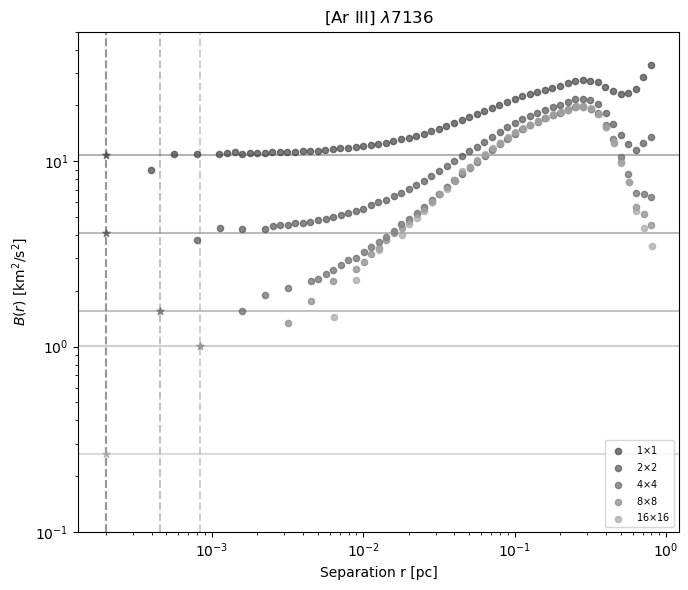

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

for i, name in enumerate(data_in):
    d = data[name]
    color = colors[i]

    if d['noise'] is not None:
        ax.axhline(d['noise'], ls='-', color=color, alpha=0.4)

    if d['s0'] is not None:
        ax.axvline(d['s0'], ls='--', color=color, alpha=0.4)

    if d['s0'] is not None and d['noise'] is not None:
        ax.scatter(
            d['s0'], d['noise'],
            color=color, zorder=10, alpha=0.7, s=30, marker='*'
        )

    ax.scatter(
        d['r'], d['B'],
        label=name, color=color, zorder=10, alpha=0.7, s=20
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Separation r [pc]')
ax.set_ylabel(r'$B(r)$ [km$^2$/s$^2$]')
ax.set_title(data[data_in[0]]['line'] if data_in else 'Line')
ax.legend(loc='lower right', fontsize=7)
ax.set_ylim(0.1, 50)
plt.tight_layout()
plt.show()

KPNO results

In [15]:
fits_path = "fits_ready/KPNO-M42-H-bin0.fits"

with fits.open(fits_path) as hdul:
    hdr = hdul[0].header
    
#noise    = hdul[0].header['NOISE']
#m3D      = hdul[0].header['M3D']
#ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']

In [16]:
from astropy.table import Table
t = Table.read(fits_path, hdu="TABLE")
data_kpno = t.to_pandas()
param_k = Table.read(fits_path, hdu="PARAMETERS")
param_k = param_k.to_pandas()
mask = np.array(data_kpno["N pairs"]) > 0
B_kpno        = np.array(data_kpno['Unweighted B(r)'])[mask]
r_kpno        = np.array(10 ** np.array(data_kpno['log10 r'])* pix * pc)[mask]

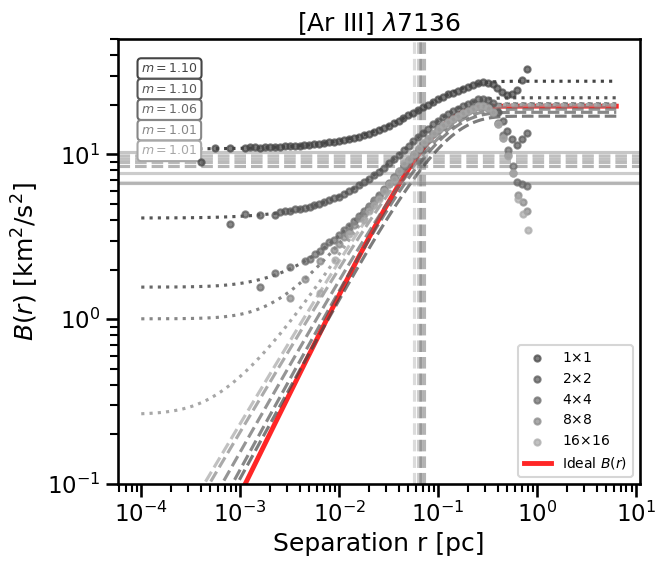

In [28]:
sns.set_context("talk")


fig, ax = plt.subplots(figsize=(7, 6))
rgrid = np.logspace(-4, 0.8, 300)

for i, name in enumerate(data_in):
    d = data[name]
    color = colors[i]
    marker = markers[i % len(markers)]

    if d['sig2'] is not None:
        ax.axhline(d['sig2'], ls='--', color=color, alpha=0.4)

    if d['r0'] is not None:
        ax.axvline(d['r0'], ls='--', color=color, alpha=0.4)

    ax.scatter(
        d['r'], d['B'],
        label=name, color=color, zorder=10, alpha=0.7, s=20, marker=marker
    )

    if all(d[k] is not None for k in ['r0', 'sig2', 'm', 's0', 'noise']):
        ax.plot(
            rgrid,
            bfunc.bfunc03s(rgrid, d['r0'], d['sig2'], d['m'], d['s0'], d['noise']),
            color=color, ls=':'
        )

    if all(d[k] is not None for k in ['r0', 'sig2', 'm']):
        ax.plot(
            rgrid,
            bfunc.bfunc00s(rgrid, d['r0'], d['sig2'], d['m']),
            color=color, ls='--', alpha=0.7
        )

    if d['sig2_meta'] is not None:
        ax.axhline(d['sig2_meta'], ls='-', color=color, alpha=0.3)

    if d['m'] is not None:
        x_annot, y_annot = annotation_coords[name]
        ax.text(
            x_annot, y_annot,
            f"$m = {d['m']:.2f}$",
            color=color,
            fontsize=9,
            bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3')
        )

#ax.plot(r_kpno, B_kpno, color='red', lw=3.5, zorder=10, label = r'KPNO H$\alpha$', alpha = 0.65)
ax.plot(rgrid, 
        bfunc.bfunc00s(rgrid,  0.062,9.81, param_k.m[0]), 
        color='red', lw=3.5, zorder=0,  label = 'Ideal $B(r)$', alpha = 0.85)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Separation r [pc]')
ax.set_ylabel(r'$B(r)$ [km$^2$/s$^2$]')
ax.set_title(data[data_in[0]]['line'] if data_in else 'Line')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0.1, 50)
plt.tight_layout()
plt.savefig('Imgs/Brs_Ar.jpg', bbox_inches='tight')
plt.savefig('Imgs/Brs_Ar.pdf', bbox_inches='tight')
plt.show()

# For paper table results

## User Function

In [18]:
def print_fit_summary(results):
    L = results['meta']['BOX_SIZE']
    pc = results['meta']['PC']
    FWHM = 2.35

    sig2, sig2_plus, sig2_minus = results['fit']['sig2']
    m, m_plus, m_minus = results['fit']['m']
    r0, r0_plus, r0_minus = results['fit']['r0']
    s0, s0_plus, s0_minus = results['fit']['s0']
    noise, noise_plus, noise_minus = results['fit']['noise']

    print(f"{sig2:.2f}\\PM{{{sig2_plus:.2f}}}{{{sig2_minus:.2f}}}")
    print(f"{noise:.2f}\\PM{{{noise_plus:.2f}}}{{{noise_minus:.2f}}}")
    print(f"{s0:.4f}\\PM{{{s0_plus:.4f}}}{{{s0_minus:.4f}}}")
    print(f"{r0:.2f}\\PM{{{r0_plus:.2f}}}{{{r0_minus:.2f}}}")
    print(f"{L:.2f}")
    print(f"{m:.2f}\\PM{{{m_plus:.2f}}}{{{m_minus:.2f}}}")
    print(f"{L/r0:.2f}")
    print(f"{s0/r0:.4f}")
    print(f"{s0/pc * FWHM:.4f}\\PM{{{s0_plus/pc * FWHM:.4f}}}{{{s0_minus/pc * FWHM:.4f}}}")

    print(f"noise = {(noise + noise_plus):.4f} (km/s)^2")
    print(f"s0(rms) = {(s0 + s0_plus):.4f} pc")
    print(f"s0(FWHM) = {((s0 + s0_plus)/pc * FWHM):.4f} arcsec")

In [19]:
def print_fit_summary_row(results):
    L   = results['meta']['BOX_SIZE']
    pc  = results['meta']['PC']   # [pc / arcsec]
    pix = results['meta']['PIX']  # Instrument resolution [arcsec / pix]
    binsize = results['meta']['BINSIZE'] # [pix]
    FWHM = 2.35

    sig2, sig2_plus, sig2_minus = results['fit']['sig2']
    m, m_plus, m_minus = results['fit']['m']
    r0, r0_plus, r0_minus = results['fit']['r0']
    s0, s0_plus, s0_minus = results['fit']['s0']
    noise, noise_plus, noise_minus = results['fit']['noise']

    row = " & ".join([
        f"{sig2:.2f}\\PM{{{sig2_plus:.2f}}}{{{sig2_minus:.2f}}}",
        f"{noise:.2f}\\PM{{{noise_plus:.2f}}}{{{noise_minus:.2f}}}",
        f"{s0:.4f}\\PM{{{s0_plus:.4f}}}{{{s0_minus:.4f}}}",
        f"{r0:.3f}\\PM{{{r0_plus:.3f}}}{{{r0_minus:.3f}}}",
        f"{L:.2f}",
        f"{m:.2f}\\PM{{{m_plus:.2f}}}{{{m_minus:.2f}}}",
        f"{L/r0:.2f}",
        f"{s0/r0:.4f}",
        f"{(pc*pix)/r0:.4f}",
        f"{s0/pc * FWHM:.4f}\\PM{{{s0_plus/pc * FWHM:.4f}}}{{{s0_minus/pc * FWHM:.4f}}}",
    ])

    print(row)
    print(f"noise      = {(noise + noise_plus):.2f} (km/s)^2")
    print(f"s0(rms)    = {(s0 + s0_plus):.4f} pc")
    print(f"s0(FWHM)   = {((s0 + s0_plus)/pc * FWHM):.2f} arcsec")
    print(f"Binsize/r0 = {(pc*pix)/r0:.3f}" )

## Fit results

In [20]:
print_fit_summary_row(H_)

8.53\PM{0.53}{0.30} & 10.80\PM{0.23}{0.08} & 0.0002\PM{0.0023}{-0.0000} & 0.071\PM{0.006}{0.004} & 0.64 & 1.10\PM{0.06}{0.07} & 8.99 & 0.0028 & 0.0056 & 0.2350\PM{2.6760}{-0.0171}
noise      = 11.02 (km/s)^2
s0(rms)    = 0.0025 pc
s0(FWHM)   = 2.91 arcsec
Binsize/r0 = 0.006


In [21]:
#print_fit_summary_row(Hsbm_)

In [22]:
print_fit_summary_row(H1_)

9.00\PM{0.29}{0.21} & 4.11\PM{0.17}{0.04} & 0.0002\PM{0.0011}{-0.0000} & 0.067\PM{0.003}{0.002} & 0.64 & 1.10\PM{0.04}{0.03} & 9.63 & 0.0030 & 0.0119 & 0.2350\PM{1.2987}{-0.0156}
noise      = 4.28 (km/s)^2
s0(rms)    = 0.0013 pc
s0(FWHM)   = 1.53 arcsec
Binsize/r0 = 0.012


In [23]:
print_fit_summary_row(H2_)

9.40\PM{0.25}{0.20} & 1.56\PM{0.15}{0.08} & 0.0005\PM{0.0007}{0.0002} & 0.065\PM{0.003}{0.002} & 0.64 & 1.06\PM{0.03}{0.03} & 9.88 & 0.0070 & 0.0245 & 0.5378\PM{0.8711}{0.2784}
noise      = 1.71 (km/s)^2
s0(rms)    = 0.0012 pc
s0(FWHM)   = 1.41 arcsec
Binsize/r0 = 0.024


In [24]:
print_fit_summary_row(H3_)

9.81\PM{0.30}{0.22} & 1.00\PM{0.30}{0.21} & 0.0008\PM{0.0013}{0.0006} & 0.062\PM{0.003}{0.002} & 0.64 & 1.01\PM{0.03}{0.03} & 10.34 & 0.0135 & 0.0514 & 0.9842\PM{1.5657}{0.6943}
noise      = 1.31 (km/s)^2
s0(rms)    = 0.0022 pc
s0(FWHM)   = 2.55 arcsec
Binsize/r0 = 0.051


In [25]:
print_fit_summary_row(H4_)

9.94\PM{0.35}{0.25} & 0.26\PM{0.82}{0.09} & 0.0002\PM{0.0027}{-0.0001} & 0.057\PM{0.003}{0.001} & 0.64 & 1.01\PM{0.05}{0.04} & 11.23 & 0.0035 & 0.1116 & 0.2350\PM{3.2129}{-0.0805}
noise      = 1.09 (km/s)^2
s0(rms)    = 0.0029 pc
s0(FWHM)   = 3.45 arcsec
Binsize/r0 = 0.112


In [26]:
def print_fit_summary_row(results):
    L   = results['meta']['BOX_SIZE']
    pc  = results['meta']['PC']   # [pc / arcsec]
    pix = results['meta']['PIX']  # Instrument resolution [arcsec / pix]
    binsize = results['meta']['BINSIZE'] # [pix]
    FWHM = 2.35

    sig2, sig2_plus, sig2_minus = results['fit']['sig2']
    m, m_plus, m_minus = results['fit']['m']
    r0, r0_plus, r0_minus = results['fit']['r0']
    s0, s0_plus, s0_minus = results['fit']['s0']
    noise, noise_plus, noise_minus = results['fit']['noise']

    row = " & ".join([
        f"{sig2:.2f}\\PM{{{sig2_plus:.2f}}}{{{sig2_minus:.2f}}}",
        f"{noise:.2f}\\PM{{{noise_plus:.2f}}}{{{noise_minus:.2f}}}",
        f"{(2*sig2/noise)**0.5:.2f}",
        f"{s0:.4f}\\PM{{{s0_plus:.4f}}}{{{s0_minus:.4f}}}",
        f"{r0:.3f}\\PM{{{r0_plus:.3f}}}{{{r0_minus:.3f}}}",
        f"{L:.2f}",
        f"{m:.2f}\\PM{{{m_plus:.2f}}}{{{m_minus:.2f}}}",
        #f"{L/r0:.2f}",
        f"{s0/r0:.4f}",
        f"{(pc*pix)/r0:.4f}",
        #f"{s0/pc * FWHM:.4f}\\PM{{{s0_plus/pc * FWHM:.4f}}}{{{s0_minus/pc * FWHM:.4f}}}",
    ])

    print(row)
    print(f"noise      = {(noise + noise_plus):.2f} (km/s)^2")
    print(f"s0(rms)    = {(s0 + s0_plus):.4f} pc")
  #  print(f"s0(FWHM)   = {((s0 + s0_plus)/pc * FWHM):.2f} arcsec")
   # print(f"Binsize/r0 = {(pc*pix*2**binsize)/r0:.2f}" )

In [27]:
print_fit_summary_row(H_)
print_fit_summary_row(H1_)
print_fit_summary_row(H2_)
print_fit_summary_row(H3_)
print_fit_summary_row(H4_)

8.53\PM{0.53}{0.30} & 10.80\PM{0.23}{0.08} & 1.26 & 0.0002\PM{0.0023}{-0.0000} & 0.071\PM{0.006}{0.004} & 0.64 & 1.10\PM{0.06}{0.07} & 0.0028 & 0.0056
noise      = 11.02 (km/s)^2
s0(rms)    = 0.0025 pc
9.00\PM{0.29}{0.21} & 4.11\PM{0.17}{0.04} & 2.09 & 0.0002\PM{0.0011}{-0.0000} & 0.067\PM{0.003}{0.002} & 0.64 & 1.10\PM{0.04}{0.03} & 0.0030 & 0.0119
noise      = 4.28 (km/s)^2
s0(rms)    = 0.0013 pc
9.40\PM{0.25}{0.20} & 1.56\PM{0.15}{0.08} & 3.47 & 0.0005\PM{0.0007}{0.0002} & 0.065\PM{0.003}{0.002} & 0.64 & 1.06\PM{0.03}{0.03} & 0.0070 & 0.0245
noise      = 1.71 (km/s)^2
s0(rms)    = 0.0012 pc
9.81\PM{0.30}{0.22} & 1.00\PM{0.30}{0.21} & 4.42 & 0.0008\PM{0.0013}{0.0006} & 0.062\PM{0.003}{0.002} & 0.64 & 1.01\PM{0.03}{0.03} & 0.0135 & 0.0514
noise      = 1.31 (km/s)^2
s0(rms)    = 0.0022 pc
9.94\PM{0.35}{0.25} & 0.26\PM{0.82}{0.09} & 8.68 & 0.0002\PM{0.0027}{-0.0001} & 0.057\PM{0.003}{0.001} & 0.64 & 1.01\PM{0.05}{0.04} & 0.0035 & 0.1116
noise      = 1.09 (km/s)^2
s0(rms)    = 0.0029 pc
